# CatBoost Two-Step Anomaly Detection and Attack Classification

This notebook implements a comprehensive two-step approach for network intrusion detection using the CICIDS 2017 dataset:

1. **Anomaly Detection**: Binary classification (Normal vs Attack)
2. **Attack Classification**: Multi-class classification of attack types

## Features:
- Comprehensive data preprocessing with feature engineering
- Optuna hyperparameter optimization
- Cross-validation with overfitting prevention
- MLflow integration for experiment tracking
- Robust evaluation metrics and visualization

## Setup and Imports

In [1]:
# Install required packages if not already installed
# !pip install -r requirements_catboost.txt

import os
import json
import pickle
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any, Union
from dataclasses import dataclass
import logging

import pandas as pd
import numpy as np
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight
import catboost as cb
import optuna
import mlflow
import mlflow.catboost
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("✅ All imports successful!")
print(f"CatBoost version: {cb.__version__}")
print(f"Optuna version: {optuna.__version__}")

✅ All imports successful!
CatBoost version: 1.2.8
Optuna version: 4.4.0


## Configuration

In [2]:
@dataclass
class ModelConfig:
    """Configuration for the two-step CatBoost model."""
    data_dir: Path
    output_dir: Path
    test_size: float = 0.2
    val_size: float = 0.1
    random_state: int = 42
    n_trials: int = 50  # Reduced for notebook
    cv_folds: int = 5
    early_stopping_rounds: int = 50
    verbose: bool = True

# Initialize configuration
config = ModelConfig(
    data_dir=Path("data"),
    output_dir=Path("models/cicids_catboost_notebook"),
    n_trials=30,  # Faster for notebook execution
    verbose=True
)

print(f"Configuration:")
print(f"  Data directory: {config.data_dir}")
print(f"  Output directory: {config.output_dir}")
print(f"  Optimization trials: {config.n_trials}")
print(f"  Test size: {config.test_size}")
print(f"  Validation size: {config.val_size}")

Configuration:
  Data directory: data
  Output directory: models\cicids_catboost_notebook
  Optimization trials: 30
  Test size: 0.2
  Validation size: 0.1


## Data Loading and Exploration

In [3]:
def load_cicids_datasets(data_dir: Path) -> pd.DataFrame:
    """Load and combine all CICIDS 2017 CSV files."""
    logger.info("Loading CICIDS 2017 datasets...")
    
    data_folders = [
        data_dir / "TrafficLabelling",
        data_dir / "MachineLearningCVE"
    ]
    
    dataframes = []
    file_info = []
    
    for folder in data_folders:
        if not folder.exists():
            logger.warning(f"Folder {folder} does not exist, skipping...")
            continue
            
        csv_files = list(folder.glob("*.csv"))
        logger.info(f"Found {len(csv_files)} CSV files in {folder}")
        
        for csv_file in csv_files:
            try:
                print(f"Loading {csv_file.name}...")
                
                # Try different encodings
                for encoding in ['utf-8', 'latin-1', 'cp1252', 'iso-8859-1']:
                    try:
                        df = pd.read_csv(csv_file, encoding=encoding, low_memory=False)
                        break
                    except UnicodeDecodeError:
                        continue
                else:
                    print(f"❌ Could not decode {csv_file.name}")
                    continue
                
                # Standardize column names
                df.columns = df.columns.str.strip()
                if ' Label' in df.columns:
                    df = df.rename(columns={' Label': 'Label'})
                elif 'label' in df.columns:
                    df = df.rename(columns={'label': 'Label'})
                
                if 'Label' not in df.columns:
                    print(f"⚠️ No Label column found in {csv_file.name}")
                    continue
                
                dataframes.append(df)
                file_info.append({
                    'file': csv_file.name,
                    'samples': len(df),
                    'features': len(df.columns) - 1,
                    'labels': df['Label'].nunique()
                })
                print(f"✅ Loaded {len(df):,} samples, {len(df.columns)} columns")
                
            except Exception as e:
                print(f"❌ Error loading {csv_file.name}: {str(e)}")
    
    if not dataframes:
        raise ValueError("No valid datasets found!")
    
    # Combine all dataframes
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    # Display loading summary
    file_df = pd.DataFrame(file_info)
    print("\n📊 Dataset Loading Summary:")
    print(file_df.to_string(index=False))
    print(f"\n🎯 Total Combined Dataset: {len(combined_df):,} samples, {len(combined_df.columns)} columns")
    
    return combined_df

# Load the datasets
df_raw = load_cicids_datasets(config.data_dir)
print(f"\nDataset shape: {df_raw.shape}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

2025-09-01 14:01:04,761 - INFO - Loading CICIDS 2017 datasets...
2025-09-01 14:01:04,766 - INFO - Found 8 CSV files in data\TrafficLabelling
2025-09-01 14:01:04,766 - INFO - Found 8 CSV files in data\TrafficLabelling


Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
✅ Loaded 225,745 samples, 85 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
✅ Loaded 225,745 samples, 85 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
✅ Loaded 286,467 samples, 85 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
✅ Loaded 286,467 samples, 85 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
✅ Loaded 191,033 samples, 85 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
✅ Loaded 191,033 samples, 85 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
✅ Loaded 529,918 samples, 85 columns
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
✅ Loaded 529,918 samples, 85 columns
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
✅ Loaded 288,602 samples, 85 columns
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
✅ Loaded 288,602 samples, 85 columns
Loading Thursday-WorkingHours-Morning-

2025-09-01 14:01:31,035 - INFO - Found 8 CSV files in data\MachineLearningCVE


✅ Loaded 692,703 samples, 85 columns
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
✅ Loaded 225,745 samples, 79 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
✅ Loaded 225,745 samples, 79 columns
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
✅ Loaded 286,467 samples, 79 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
✅ Loaded 286,467 samples, 79 columns
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
✅ Loaded 191,033 samples, 79 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
✅ Loaded 191,033 samples, 79 columns
Loading Monday-WorkingHours.pcap_ISCX.csv...
✅ Loaded 529,918 samples, 79 columns
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
✅ Loaded 529,918 samples, 79 columns
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
✅ Loaded 288,602 samples, 79 columns
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
✅ Loaded 288,602 samples, 79 columns
L

🏷️ Label Distribution:
Label
BENIGN                        4546194
DoS Hulk                       462146
PortScan                       317860
DDoS                           256054
DoS GoldenEye                   20586
FTP-Patator                     15876
SSH-Patator                     11794
DoS slowloris                   11592
DoS Slowhttptest                10998
Bot                              3932
Web Attack � Brute Force         1507
Web Attack  Brute Force         1507
Web Attack  XSS                  652
Web Attack � XSS                  652
Infiltration                       72
Heartbleed                         22
Web Attack  Sql Injection         21
Web Attack � Sql Injection         21
Name: count, dtype: int64
Label
BENIGN                        4546194
DoS Hulk                       462146
PortScan                       317860
DDoS                           256054
DoS GoldenEye                   20586
FTP-Patator                     15876
SSH-Patator                

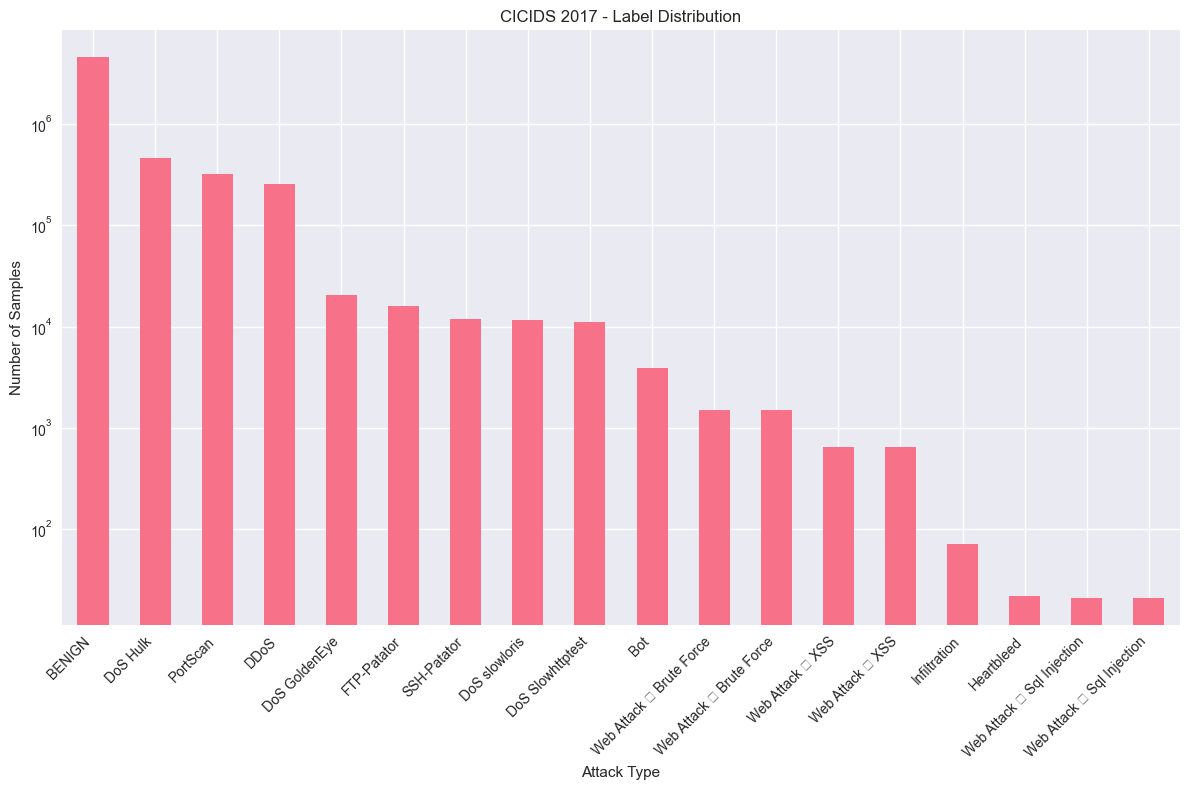


⚖️ Class Balance:
  Benign: 4,546,194 (76.41%)
  Attack: 1,403,894 (23.59%)
  Imbalance ratio: 1:0.31


In [4]:
# Explore label distribution
print("🏷️ Label Distribution:")
label_counts = df_raw['Label'].value_counts()
print(label_counts)

# Visualize label distribution
plt.figure(figsize=(12, 8))
label_counts.plot(kind='bar')
plt.title('CICIDS 2017 - Label Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.yscale('log')  # Log scale due to large imbalance
plt.tight_layout()
plt.show()

# Calculate class balance
benign_count = (df_raw['Label'] == 'BENIGN').sum()
attack_count = (df_raw['Label'] != 'BENIGN').sum()
print(f"\n⚖️ Class Balance:")
print(f"  Benign: {benign_count:,} ({benign_count/len(df_raw)*100:.2f}%)")
print(f"  Attack: {attack_count:,} ({attack_count/len(df_raw)*100:.2f}%)")
print(f"  Imbalance ratio: 1:{attack_count/benign_count:.2f}")

## Data Preprocessing and Feature Engineering

In [5]:
def preprocess_cicids_data(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    """Clean and preprocess the CICIDS dataset."""
    logger.info("Cleaning and preprocessing data...")
    
    # Remove identifier columns
    id_columns = [
        'Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
        'Src IP', 'Dst IP', 'Flow.ID', 'Src.IP', 'Dst.IP'
    ]
    
    existing_id_cols = [col for col in id_columns if col in df.columns]
    if existing_id_cols:
        df = df.drop(columns=existing_id_cols)
        print(f"Removed identifier columns: {existing_id_cols}")
    
    # Handle missing values
    print(f"Missing values before cleaning: {df.isnull().sum().sum():,}")
    
    # Convert object columns to numeric where possible
    for col in df.columns:
        if col != 'Label' and df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Get numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'Label' in numeric_cols:
        numeric_cols.remove('Label')
    
    # Fill missing values with median
    for col in numeric_cols:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    
    # Handle infinite values
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    
    print(f"Missing values after cleaning: {df.isnull().sum().sum():,}")
    print(f"Final numeric columns: {len(numeric_cols)}")
    
    return df, numeric_cols

# Preprocess the data
df_clean, feature_columns = preprocess_cicids_data(df_raw.copy())
print(f"\n✅ Preprocessing completed!")
print(f"Features available: {len(feature_columns)}")
print(f"Sample feature names: {feature_columns[:10]}")

2025-09-01 14:02:10,268 - INFO - Cleaning and preprocessing data...


Removed identifier columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
Missing values before cleaning: 29,040,964
Missing values before cleaning: 29,040,964
Missing values after cleaning: 288,602
Final numeric columns: 80

✅ Preprocessing completed!
Features available: 80
Sample feature names: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min']
Missing values after cleaning: 288,602
Final numeric columns: 80

✅ Preprocessing completed!
Features available: 80
Sample feature names: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min']


In [6]:
def create_labels_and_engineer_features(df: pd.DataFrame, feature_cols: List[str]) -> Tuple[pd.DataFrame, Dict, LabelEncoder]:
    """Create binary and multi-class labels, and engineer additional features."""
    logger.info("Creating labels and engineering features...")
    
    # Create binary labels (0=BENIGN, 1=ATTACK)
    df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)
    
    # Filter attack types with sufficient samples
    attack_data = df[df['is_attack'] == 1].copy()
    attack_type_counts = attack_data['Label'].value_counts()
    
    min_samples = 100
    valid_attack_types = attack_type_counts[attack_type_counts >= min_samples].index.tolist()
    
    print(f"Attack types with ≥{min_samples} samples: {len(valid_attack_types)}")
    for attack_type in valid_attack_types:
        count = attack_type_counts[attack_type]
        print(f"  {attack_type}: {count:,}")
    
    # Encode attack types
    label_encoder = LabelEncoder()
    attack_data_filtered = attack_data[attack_data['Label'].isin(valid_attack_types)]
    attack_data_filtered['attack_type'] = label_encoder.fit_transform(attack_data_filtered['Label'])
    
    # Add attack type labels back to main dataframe
    df['attack_type'] = -1  # Default for benign traffic
    df.loc[attack_data_filtered.index, 'attack_type'] = attack_data_filtered['attack_type']
    
    # Feature engineering
    print("\n🔧 Engineering features...")
    
    # Log transform for skewed features
    skewed_features = []
    for col in feature_cols[:20]:  # Limit to avoid too many features
        if df[col].skew() > 2 and df[col].min() >= 0:  # Only for positive skewed features
            df[f'{col}_log'] = np.log1p(df[col])
            skewed_features.append(f'{col}_log')
    
    # Ratio features
    ratio_features = []
    packet_cols = [col for col in feature_cols if 'packet' in col.lower()][:5]
    byte_cols = [col for col in feature_cols if 'byte' in col.lower()][:5]
    
    if len(packet_cols) >= 2:
        for i, col1 in enumerate(packet_cols[:-1]):
            col2 = packet_cols[i+1]
            ratio_name = f'{col1}_{col2}_ratio'
            df[ratio_name] = np.where(
                df[col2] != 0, 
                df[col1] / (df[col2] + 1e-10), 
                0
            )
            ratio_features.append(ratio_name)
    
    # Statistical features
    stat_features = []
    if len(feature_cols) >= 10:
        sample_features = feature_cols[:10]
        feature_data = df[sample_features].fillna(0)
        
        df['features_mean'] = feature_data.mean(axis=1)
        df['features_std'] = feature_data.std(axis=1)
        df['features_max'] = feature_data.max(axis=1)
        df['features_min'] = feature_data.min(axis=1)
        
        stat_features = ['features_mean', 'features_std', 'features_max', 'features_min']
    
    # Update feature columns
    new_features = skewed_features + ratio_features + stat_features
    all_features = feature_cols + new_features
    
    print(f"  Original features: {len(feature_cols)}")
    print(f"  Log features: {len(skewed_features)}")
    print(f"  Ratio features: {len(ratio_features)}")
    print(f"  Statistical features: {len(stat_features)}")
    print(f"  Total features: {len(all_features)}")
    
    label_info = {
        'binary_distribution': df['is_attack'].value_counts().to_dict(),
        'valid_attack_types': valid_attack_types,
        'attack_type_mapping': {attack_type: idx for idx, attack_type in enumerate(label_encoder.classes_)}
    }
    
    return df, label_info, label_encoder, all_features

# Create labels and engineer features
df_processed, label_info, label_encoder, final_features = create_labels_and_engineer_features(
    df_clean, feature_columns
)

print(f"\n✅ Feature engineering completed!")
print(f"Final dataset shape: {df_processed.shape}")
print(f"Binary classification - Attack ratio: {df_processed['is_attack'].mean():.4f}")
print(f"Attack types for classification: {len(label_info['valid_attack_types'])}")

2025-09-01 14:02:39,627 - INFO - Creating labels and engineering features...


Attack types with ≥100 samples: 13
  DoS Hulk: 462,146
  PortScan: 317,860
  DDoS: 256,054
  DoS GoldenEye: 20,586
  FTP-Patator: 15,876
  SSH-Patator: 11,794
  DoS slowloris: 11,592
  DoS Slowhttptest: 10,998
  Bot: 3,932
  Web Attack � Brute Force: 1,507
  Web Attack  Brute Force: 1,507
  Web Attack  XSS: 652
  Web Attack � XSS: 652

🔧 Engineering features...

🔧 Engineering features...
  Original features: 80
  Log features: 14
  Ratio features: 4
  Statistical features: 4
  Total features: 102

✅ Feature engineering completed!
Final dataset shape: (5950088, 105)
Binary classification - Attack ratio: 0.2359
Attack types for classification: 13
  Original features: 80
  Log features: 14
  Ratio features: 4
  Statistical features: 4
  Total features: 102

✅ Feature engineering completed!
Final dataset shape: (5950088, 105)
Binary classification - Attack ratio: 0.2359
Attack types for classification: 13


## Data Splitting and Scaling

In [7]:
def prepare_data_splits(df: pd.DataFrame, features: List[str], config: ModelConfig) -> Dict:
    """Prepare train/val/test splits for both binary and multiclass tasks."""
    logger.info("Preparing data splits...")
    
    # Features
    X = df[features].values
    
    # Binary classification data
    y_binary = df['is_attack'].values
    
    # Attack classification data (only attacks)
    attack_mask = df['is_attack'] == 1
    X_attacks = X[attack_mask]
    y_attacks = df.loc[attack_mask, 'attack_type'].values
    
    # Scale features
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    X_attacks_scaled = scaler.transform(X_attacks)
    
    # Binary classification splits
    X_train_bin, X_temp_bin, y_train_bin, y_temp_bin = train_test_split(
        X_scaled, y_binary, 
        test_size=config.test_size + config.val_size,
        stratify=y_binary,
        random_state=config.random_state
    )
    
    val_size_adjusted = config.val_size / (config.test_size + config.val_size)
    X_val_bin, X_test_bin, y_val_bin, y_test_bin = train_test_split(
        X_temp_bin, y_temp_bin,
        test_size=val_size_adjusted,
        stratify=y_temp_bin,
        random_state=config.random_state
    )
    
    # Attack classification splits
    X_train_att, X_temp_att, y_train_att, y_temp_att = train_test_split(
        X_attacks_scaled, y_attacks,
        test_size=config.test_size + config.val_size,
        stratify=y_attacks,
        random_state=config.random_state
    )
    
    X_val_att, X_test_att, y_val_att, y_test_att = train_test_split(
        X_temp_att, y_temp_att,
        test_size=val_size_adjusted,
        stratify=y_temp_att,
        random_state=config.random_state
    )
    
    data_splits = {
        'scaler': scaler,
        'features': features,
        'binary': {
            'train': (X_train_bin, y_train_bin),
            'val': (X_val_bin, y_val_bin),
            'test': (X_test_bin, y_test_bin)
        },
        'multiclass': {
            'train': (X_train_att, y_train_att),
            'val': (X_val_att, y_val_att),
            'test': (X_test_att, y_test_att)
        }
    }
    
    # Display split information
    print("📊 Data splits created:")
    print(f"Binary classification:")
    print(f"  Train: {len(X_train_bin):,} | Val: {len(X_val_bin):,} | Test: {len(X_test_bin):,}")
    print(f"  Train attack ratio: {y_train_bin.mean():.4f}")
    print(f"Attack classification:")
    print(f"  Train: {len(X_train_att):,} | Val: {len(X_val_att):,} | Test: {len(X_test_att):,}")
    print(f"  Classes: {len(np.unique(y_attacks))}")
    
    return data_splits

# Prepare data splits
data_splits = prepare_data_splits(df_processed, final_features, config)
print("\n✅ Data preparation completed!")

2025-09-01 14:02:47,543 - INFO - Preparing data splits...


📊 Data splits created:
Binary classification:
  Train: 4,165,061 | Val: 1,190,018 | Test: 595,009
  Train attack ratio: 0.2359
Attack classification:
  Train: 982,725 | Val: 280,779 | Test: 140,390
  Classes: 14

✅ Data preparation completed!

✅ Data preparation completed!


## Hyperparameter Optimization with Optuna

In [ ]:
def optimize_binary_classifier(data_splits: Dict, n_trials: int = 5) -> Dict[str, Any]:
    """Optimize hyperparameters for binary classification."""
    logger.info("Optimizing binary classifier hyperparameters...")
    
    X_train, y_train = data_splits['binary']['train']
    X_val, y_val = data_splits['binary']['val']
    
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
            'od_type': 'Iter',
            'od_wait': 50,
            'random_seed': 42,
            'verbose': False,
            'allow_writing_files': False,
            'task_type': 'CPU'
        }
        
        # Add class weights for imbalanced data
        class_weights = compute_class_weight(
            'balanced', classes=np.unique(y_train), y=y_train
        )
        params['class_weights'] = class_weights.tolist()
        
        model = cb.CatBoostClassifier(**params)
        
        try:
            model.fit(
                X_train, y_train,
                eval_set=(X_val, y_val),
                verbose=False,
                plot=False
            )
            
            # Use F1 score as optimization metric
            y_pred = model.predict(X_val)
            f1 = f1_score(y_val, y_pred)
            
            # Penalty for overfitting
            train_f1 = f1_score(y_train, model.predict(X_train))
            overfitting_penalty = max(0, train_f1 - f1 - 0.05)
            
            return f1 - overfitting_penalty
            
        except Exception as e:
            return 0.0
    
    study = optuna.create_study(direction='maximize')
    
    # Progress callback
    def progress_callback(study, trial):
        if trial.number % 5 == 0:
            print(f"Trial {trial.number}: Best F1 = {study.best_value:.4f}")
    
    study.optimize(objective, n_trials=n_trials, callbacks=[progress_callback])
    
    print(f"\n🎯 Binary classifier optimization completed:")
    print(f"  Best F1 score: {study.best_value:.4f}")
    print(f"  Best parameters: {study.best_params}")
    
    return study.best_params

# Optimize binary classifier
binary_best_params = optimize_binary_classifier(data_splits, config.n_trials)

2025-09-01 14:03:41,372 - INFO - Optimizing binary classifier hyperparameters...
[I 2025-09-01 14:03:41,388] A new study created in memory with name: no-name-0a10b708-69b7-4a4d-a176-3a623242a0bb
[I 2025-09-01 14:03:41,388] A new study created in memory with name: no-name-0a10b708-69b7-4a4d-a176-3a623242a0bb
[I 2025-09-01 14:12:05,082] Trial 0 finished with value: 0.9987441387210849 and parameters: {'iterations': 1307, 'learning_rate': 0.2890669446275848, 'depth': 10, 'l2_leaf_reg': 6.672271358804102, 'border_count': 54, 'bagging_temperature': 0.5456302350877776, 'random_strength': 5.935505754852367}. Best is trial 0 with value: 0.9987441387210849.
[I 2025-09-01 14:12:05,082] Trial 0 finished with value: 0.9987441387210849 and parameters: {'iterations': 1307, 'learning_rate': 0.2890669446275848, 'depth': 10, 'l2_leaf_reg': 6.672271358804102, 'border_count': 54, 'bagging_temperature': 0.5456302350877776, 'random_strength': 5.935505754852367}. Best is trial 0 with value: 0.998744138721084

Trial 0: Best F1 = 0.9987


[I 2025-09-01 14:19:23,016] Trial 1 finished with value: 0.9986037618391214 and parameters: {'iterations': 1309, 'learning_rate': 0.25405096525927456, 'depth': 9, 'l2_leaf_reg': 3.634685703008868, 'border_count': 97, 'bagging_temperature': 0.27867788582792485, 'random_strength': 6.534991383353318}. Best is trial 0 with value: 0.9987441387210849.
[I 2025-09-01 15:05:46,061] Trial 2 finished with value: 0.998738831364499 and parameters: {'iterations': 999, 'learning_rate': 0.012502509707542148, 'depth': 10, 'l2_leaf_reg': 3.477112294230055, 'border_count': 252, 'bagging_temperature': 0.876658720130598, 'random_strength': 1.7189058896237341}. Best is trial 0 with value: 0.9987441387210849.
[I 2025-09-01 15:05:46,061] Trial 2 finished with value: 0.998738831364499 and parameters: {'iterations': 999, 'learning_rate': 0.012502509707542148, 'depth': 10, 'l2_leaf_reg': 3.477112294230055, 'border_count': 252, 'bagging_temperature': 0.876658720130598, 'random_strength': 1.7189058896237341}. Best

Trial 5: Best F1 = 0.9987


[W 2025-09-02 09:42:33,412] Trial 6 failed with parameters: {'iterations': 623, 'learning_rate': 0.11220176286930986, 'depth': 10, 'l2_leaf_reg': 4.900797744225151, 'border_count': 59, 'bagging_temperature': 0.2776263642727915, 'random_strength': 1.9990856948037994} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "c:\Users\madhu\AppData\Local\Programs\Python\Python311\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\madhu\AppData\Local\Temp\ipykernel_13384\588260318.py", line 34, in objective
    model.fit(
  File "c:\Users\madhu\AppData\Local\Programs\Python\Python311\Lib\site-packages\catboost\core.py", line 5245, in fit
    self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline, use_best_model,
  File "c:\Users\madhu\AppData\Local\Programs\Python\Python311\Lib\

In [ ]:
def optimize_multiclass_classifier(data_splits: Dict, n_trials: int = 5) -> Dict[str, Any]:
    """Optimize hyperparameters for multiclass classification."""
    logger.info("Optimizing multiclass classifier hyperparameters...")
    
    X_train, y_train = data_splits['multiclass']['train']
    X_val, y_val = data_splits['multiclass']['val']
    
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            'border_count': trial.suggest_int('border_count', 32, 255),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),
            'od_type': 'Iter',
            'od_wait': 50,
            'random_seed': 42,
            'verbose': False,
            'allow_writing_files': False,
            'task_type': 'CPU'
        }
        
        # Add class weights for imbalanced data
        class_weights = compute_class_weight(
            'balanced', classes=np.unique(y_train), y=y_train
        )
        params['class_weights'] = class_weights.tolist()
        
        model = cb.CatBoostClassifier(**params)
        
        try:
            model.fit(
                X_train, y_train,
                eval_set=(X_val, y_val),
                verbose=False,
                plot=False
            )
            
            # Use weighted F1 score for multiclass
            y_pred = model.predict(X_val)
            f1 = f1_score(y_val, y_pred, average='weighted')
            
            # Penalty for overfitting
            train_f1 = f1_score(y_train, model.predict(X_train), average='weighted')
            overfitting_penalty = max(0, train_f1 - f1 - 0.05)
            
            return f1 - overfitting_penalty
            
        except Exception as e:
            return 0.0
    
    study = optuna.create_study(direction='maximize')
    
    # Progress callback
    def progress_callback(study, trial):
        if trial.number % 5 == 0:
            print(f"Trial {trial.number}: Best weighted F1 = {study.best_value:.4f}")
    
    study.optimize(objective, n_trials=n_trials, callbacks=[progress_callback])
    
    print(f"\n🎯 Multiclass classifier optimization completed:")
    print(f"  Best weighted F1 score: {study.best_value:.4f}")
    print(f"  Best parameters: {study.best_params}")
    
    return study.best_params

# Optimize multiclass classifier
multiclass_best_params = optimize_multiclass_classifier(data_splits, config.n_trials)

## Final Model Training

In [ ]:
def train_final_models(data_splits: Dict, binary_params: Dict, multiclass_params: Dict) -> Tuple[cb.CatBoostClassifier, cb.CatBoostClassifier]:
    """Train final models with optimized parameters."""
    logger.info("Training final models...")
    
    # Binary classifier
    print("🔥 Training binary classifier...")
    X_train_bin, y_train_bin = data_splits['binary']['train']
    X_val_bin, y_val_bin = data_splits['binary']['val']
    
    # Add class weights
    class_weights_bin = compute_class_weight(
        'balanced', classes=np.unique(y_train_bin), y=y_train_bin
    )
    binary_params['class_weights'] = class_weights_bin.tolist()
    binary_params['verbose'] = True
    
    binary_model = cb.CatBoostClassifier(**binary_params)
    binary_model.fit(
        X_train_bin, y_train_bin,
        eval_set=(X_val_bin, y_val_bin),
        verbose=100,
        plot=True
    )
    
    # Multiclass classifier
    print("\n🔥 Training multiclass classifier...")
    X_train_multi, y_train_multi = data_splits['multiclass']['train']
    X_val_multi, y_val_multi = data_splits['multiclass']['val']
    
    # Add class weights
    class_weights_multi = compute_class_weight(
        'balanced', classes=np.unique(y_train_multi), y=y_train_multi
    )
    multiclass_params['class_weights'] = class_weights_multi.tolist()
    multiclass_params['verbose'] = True
    
    multiclass_model = cb.CatBoostClassifier(**multiclass_params)
    multiclass_model.fit(
        X_train_multi, y_train_multi,
        eval_set=(X_val_multi, y_val_multi),
        verbose=100,
        plot=True
    )
    
    return binary_model, multiclass_model

# Train final models
binary_model, multiclass_model = train_final_models(
    data_splits, binary_best_params, multiclass_best_params
)

print("\n✅ Model training completed!")

## Model Evaluation

In [ ]:
def evaluate_binary_model(model: cb.CatBoostClassifier, data_splits: Dict) -> Dict[str, float]:
    """Evaluate binary classifier performance."""
    X_test, y_test = data_splits['binary']['test']
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print("📊 Binary Classifier Test Results:")
    for metric, value in metrics.items():
        print(f"  {metric.replace('_', ' ').title()}: {value:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'])
    plt.title('Binary Classifier - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))
    
    return metrics

def evaluate_multiclass_model(model: cb.CatBoostClassifier, data_splits: Dict, label_encoder: LabelEncoder) -> Dict[str, float]:
    """Evaluate multiclass classifier performance."""
    X_test, y_test = data_splits['multiclass']['test']
    
    y_pred = model.predict(X_test)
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, average='macro'),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'precision_weighted': precision_score(y_test, y_pred, average='weighted'),
        'recall_weighted': recall_score(y_test, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted')
    }
    
    print("\n📊 Multiclass Classifier Test Results:")
    for metric, value in metrics.items():
        print(f"  {metric.replace('_', ' ').title()}: {value:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Multiclass Classifier - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Classification Report
    print("\n📋 Detailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    return metrics

# Evaluate models
binary_metrics = evaluate_binary_model(binary_model, data_splits)
multiclass_metrics = evaluate_multiclass_model(multiclass_model, data_splits, label_encoder)

## Feature Importance Analysis

In [ ]:
def analyze_feature_importance(binary_model: cb.CatBoostClassifier, 
                             multiclass_model: cb.CatBoostClassifier, 
                             features: List[str], top_n: int = 15) -> None:
    """Analyze and visualize feature importance."""
    
    # Binary classifier feature importance
    binary_importance = binary_model.get_feature_importance()
    binary_features_df = pd.DataFrame({
        'feature': features,
        'importance': binary_importance
    }).sort_values('importance', ascending=False).head(top_n)
    
    # Multiclass classifier feature importance
    multiclass_importance = multiclass_model.get_feature_importance()
    multiclass_features_df = pd.DataFrame({
        'feature': features,
        'importance': multiclass_importance
    }).sort_values('importance', ascending=False).head(top_n)
    
    # Plot feature importance
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Binary classifier
    sns.barplot(data=binary_features_df, y='feature', x='importance', ax=ax1)
    ax1.set_title(f'Binary Classifier - Top {top_n} Features')
    ax1.set_xlabel('Feature Importance')
    
    # Multiclass classifier
    sns.barplot(data=multiclass_features_df, y='feature', x='importance', ax=ax2)
    ax2.set_title(f'Multiclass Classifier - Top {top_n} Features')
    ax2.set_xlabel('Feature Importance')
    
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print(f"🔍 Top {top_n} Features for Binary Classification:")
    for i, row in binary_features_df.iterrows():
        print(f"  {row['feature']}: {row['importance']:.2f}")
    
    print(f"\n🔍 Top {top_n} Features for Multiclass Classification:")
    for i, row in multiclass_features_df.iterrows():
        print(f"  {row['feature']}: {row['importance']:.2f}")

# Analyze feature importance
analyze_feature_importance(binary_model, multiclass_model, final_features, top_n=15)

## Two-Step Prediction Pipeline

In [ ]:
def two_step_prediction(X: np.ndarray, 
                       binary_model: cb.CatBoostClassifier,
                       multiclass_model: cb.CatBoostClassifier,
                       label_encoder: LabelEncoder) -> Dict[str, np.ndarray]:
    """Make predictions using the two-step approach."""
    
    # Step 1: Binary classification
    binary_pred = binary_model.predict(X)
    binary_proba = binary_model.predict_proba(X)
    
    # Step 2: Attack classification (only for predicted attacks)
    attack_mask = binary_pred == 1
    attack_pred = np.full(len(X), -1)  # -1 for benign traffic
    attack_proba = np.zeros((len(X), len(label_encoder.classes_)))
    
    if attack_mask.sum() > 0:
        X_attacks = X[attack_mask]
        attack_pred[attack_mask] = multiclass_model.predict(X_attacks)
        attack_proba[attack_mask] = multiclass_model.predict_proba(X_attacks)
    
    return {
        'binary_predictions': binary_pred,
        'binary_probabilities': binary_proba,
        'attack_predictions': attack_pred,
        'attack_probabilities': attack_proba
    }

# Test the two-step prediction on test set
print("🧪 Testing Two-Step Prediction Pipeline:")
X_test_sample = data_splits['binary']['test'][0][:1000]  # Sample of 1000 instances

predictions = two_step_prediction(
    X_test_sample, binary_model, multiclass_model, label_encoder
)

print(f"Sample predictions shape: {X_test_sample.shape}")
print(f"Binary predictions: {predictions['binary_predictions'][:10]}")
print(f"Attack predictions: {predictions['attack_predictions'][:10]}")
print(f"Detected attacks: {(predictions['binary_predictions'] == 1).sum()} / {len(predictions['binary_predictions'])}")

# Show attack type distribution in predictions
attack_indices = predictions['attack_predictions'][predictions['attack_predictions'] != -1]
if len(attack_indices) > 0:
    attack_type_pred_counts = pd.Series(attack_indices).value_counts()
    print(f"\nPredicted attack type distribution:")
    for attack_idx, count in attack_type_pred_counts.items():
        attack_name = label_encoder.classes_[attack_idx]
        print(f"  {attack_name}: {count}")

## Model Saving and Summary

In [ ]:
# Create output directory
config.output_dir.mkdir(parents=True, exist_ok=True)

# Save models
print("💾 Saving models...")
binary_model.save_model(str(config.output_dir / 'binary_classifier.cbm'))
multiclass_model.save_model(str(config.output_dir / 'multiclass_classifier.cbm'))

# Save preprocessing components
with open(config.output_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(data_splits['scaler'], f)

with open(config.output_dir / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Save metadata
metadata = {
    'features': final_features,
    'label_info': label_info,
    'binary_params': binary_best_params,
    'multiclass_params': multiclass_best_params,
    'binary_metrics': binary_metrics,
    'multiclass_metrics': multiclass_metrics,
    'model_info': {
        'binary_iterations': binary_model.get_best_iteration(),
        'multiclass_iterations': multiclass_model.get_best_iteration(),
        'total_features': len(final_features),
        'attack_types': len(label_encoder.classes_)
    }
}

with open(config.output_dir / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"✅ Models and metadata saved to: {config.output_dir}")

# Final summary
print("\n🎉 CICIDS 2017 CatBoost Two-Step Model Training Complete!")
print("="*60)
print(f"📊 Binary Classification Results:")
print(f"   F1 Score: {binary_metrics['f1_score']:.4f}")
print(f"   ROC-AUC: {binary_metrics['roc_auc']:.4f}")
print(f"   Precision: {binary_metrics['precision']:.4f}")
print(f"   Recall: {binary_metrics['recall']:.4f}")

print(f"\n🎯 Multiclass Classification Results:")
print(f"   Weighted F1: {multiclass_metrics['f1_weighted']:.4f}")
print(f"   Macro F1: {multiclass_metrics['f1_macro']:.4f}")
print(f"   Accuracy: {multiclass_metrics['accuracy']:.4f}")

print(f"\n🔧 Model Configuration:")
print(f"   Total Features: {len(final_features)}")
print(f"   Attack Types: {len(label_encoder.classes_)}")
print(f"   Binary Model Iterations: {binary_model.get_best_iteration()}")
print(f"   Multiclass Model Iterations: {multiclass_model.get_best_iteration()}")

print(f"\n💾 Output Directory: {config.output_dir}")
print("Files saved:")
print("  - binary_classifier.cbm")
print("  - multiclass_classifier.cbm")
print("  - scaler.pkl")
print("  - label_encoder.pkl")
print("  - model_metadata.json")
print("\n🚀 Models are ready for deployment!")